# Notebook 06 — Final Comparison: Baseline vs Ridge vs Random Forest vs XGBoost vs MLP

## Purpose
This notebook presents the final comparison across all implemented models:

- **Baseline Momentum**
- **Ridge Regression**
- **Random Forest**
- **XGBoost**
- **MLP Neural Network**

## Comparison dimensions
- prediction quality
- portfolio performance
- turnover
- transaction-cost robustness

## Main focus
The key practical comparison is the **2025 hold-out test period**.

In [1]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt

## 1. Load all experiment outputs

In [ ]:
BASE_DIR = "../experiments/results/exp01_baseline_monthly"
RIDGE_DIR = "../experiments/results/exp02_linear_ridge_daily"
RF_DIR = "../experiments/results/exp04_random_forest_daily"
XGB_DIR = "../experiments/results/exp03_xgboost_daily"
MLP_DIR = "../experiments/results/exp05_nn_mlp_daily" 


def load_json(path: str) -> dict:
    with open(path, "r") as f:
        return json.load(f)


# Gross test metrics
base_test = load_json(os.path.join(BASE_DIR, "metrics_test_2025.json"))
ridge_test = load_json(os.path.join(RIDGE_DIR, "metrics_test_2025.json"))
rf_test = load_json(os.path.join(RF_DIR, "metrics_test_2025.json"))
xgb_test = load_json(os.path.join(XGB_DIR, "metrics_test_2025.json"))
mlp_test = load_json(os.path.join(MLP_DIR, "metrics_test_2025.json"))

# Cost-adjusted test metrics
base_costs = load_json(os.path.join(BASE_DIR, "metrics_test_2025_with_costs.json"))
ridge_costs = load_json(os.path.join(RIDGE_DIR, "metrics_test_2025_with_costs.json"))
rf_costs = load_json(os.path.join(RF_DIR, "metrics_test_2025_with_costs.json"))
xgb_costs = load_json(os.path.join(XGB_DIR, "metrics_test_2025_with_costs.json"))
mlp_costs = load_json(os.path.join(MLP_DIR, "metrics_test_2025_with_costs.json"))

# Prediction metrics
ridge_pred = load_json(os.path.join(RIDGE_DIR, "prediction_metrics.json"))
rf_pred = load_json(os.path.join(RF_DIR, "prediction_metrics.json"))
xgb_pred = load_json(os.path.join(XGB_DIR, "prediction_metrics.json"))
mlp_pred = load_json(os.path.join(MLP_DIR, "prediction_metrics.json"))

print("All model outputs loaded successfully.")

FileNotFoundError: [Errno 2] No such file or directory: '../experiments/results/exp01_baseline\\metrics_test_2025.json'

## 2. Gross strategy comparison (Test 2025)

In [9]:
gross_table = pd.DataFrame({
    "Metric": [
        "cumulative_return",
        "annualized_return",
        "annualized_volatility",
        "max_drawdown",
        "sharpe_ratio",
        "avg_turnover",
        "median_turnover",
        "max_turnover",
    ],
    "Baseline": [
        base_test["cumulative_return"],
        base_test["annualized_return"],
        base_test["annualized_volatility"],
        base_test["max_drawdown"],
        base_test["sharpe_ratio"],
        base_test["avg_turnover"],
        base_test["median_turnover"],
        base_test["max_turnover"],
    ],
    "Ridge": [
        ridge_test["cumulative_return"],
        ridge_test["annualized_return"],
        ridge_test["annualized_volatility"],
        ridge_test["max_drawdown"],
        ridge_test["sharpe_ratio"],
        ridge_test["avg_turnover"],
        ridge_test["median_turnover"],
        ridge_test["max_turnover"],
    ],
    "RandomForest": [
        rf_test["cumulative_return"],
        rf_test["annualized_return"],
        rf_test["annualized_volatility"],
        rf_test["max_drawdown"],
        rf_test["sharpe_ratio"],
        rf_test["avg_turnover"],
        rf_test["median_turnover"],
        rf_test["max_turnover"],
    ],
    "XGBoost": [
        xgb_test["cumulative_return"],
        xgb_test["annualized_return"],
        xgb_test["annualized_volatility"],
        xgb_test["max_drawdown"],
        xgb_test["sharpe_ratio"],
        xgb_test["avg_turnover"],
        xgb_test["median_turnover"],
        xgb_test["max_turnover"],
    ],
    "MLP": [
        mlp_test["cumulative_return"],
        mlp_test["annualized_return"],
        mlp_test["annualized_volatility"],
        mlp_test["max_drawdown"],
        mlp_test["sharpe_ratio"],
        mlp_test["avg_turnover"],
        mlp_test["median_turnover"],
        mlp_test["max_turnover"],
    ],
})

display(gross_table)

,Metric,Baseline,Ridge,RandomForest,XGBoost,MLP
0,cumulative_return,0.295569,0.055996,0.255496,0.235840,0.163806
1,annualized_return,0.295569,0.055996,0.255496,0.235840,0.163806
2,annualized_volatility,0.127714,0.165453,0.168355,0.126833,0.136884
3,max_drawdown,-0.075750,-0.116754,-0.095973,-0.063682,-0.070586
4,sharpe_ratio,2.109105,0.405857,1.440878,1.741929,1.177036
5,avg_turnover,0.150000,0.590909,0.381818,0.568182,0.513636
6,median_turnover,0.150000,0.600000,0.400000,0.650000,0.550000
7,max_turnover,0.300000,0.850000,0.600000,0.750000,0.800000


## 3. Prediction quality comparison (Test 2025)

The baseline does not produce numeric predictions, so prediction metrics apply only to the ML models.

In [10]:
pred_table = pd.DataFrame({
    "Metric": [
        "MAE",
        "RMSE",
        "R2",
        "Directional_Accuracy",
        "SpearmanRankCorr_mean",
        "TopKHitRate_mean",
        "Months_evaluated",
    ],
    "Ridge": [
        ridge_pred["test_2025"]["regression"]["MAE"],
        ridge_pred["test_2025"]["regression"]["RMSE"],
        ridge_pred["test_2025"]["regression"]["R2"],
        ridge_pred["test_2025"]["regression"]["Directional_Accuracy"],
        ridge_pred["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
        ridge_pred["test_2025"]["ranking"]["TopKHitRate_mean"],
        ridge_pred["test_2025"]["ranking"]["Months_evaluated"],
    ],
    "RandomForest": [
        rf_pred["test_2025"]["regression"]["MAE"],
        rf_pred["test_2025"]["regression"]["RMSE"],
        rf_pred["test_2025"]["regression"]["R2"],
        rf_pred["test_2025"]["regression"]["Directional_Accuracy"],
        rf_pred["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
        rf_pred["test_2025"]["ranking"]["TopKHitRate_mean"],
        rf_pred["test_2025"]["ranking"]["Months_evaluated"],
    ],
    "XGBoost": [
        xgb_pred["test_2025"]["regression"]["MAE"],
        xgb_pred["test_2025"]["regression"]["RMSE"],
        xgb_pred["test_2025"]["regression"]["R2"],
        xgb_pred["test_2025"]["regression"]["Directional_Accuracy"],
        xgb_pred["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
        xgb_pred["test_2025"]["ranking"]["TopKHitRate_mean"],
        xgb_pred["test_2025"]["ranking"]["Months_evaluated"],
    ],
    "MLP": [
        mlp_pred["test_2025"]["regression"]["MAE"],
        mlp_pred["test_2025"]["regression"]["RMSE"],
        mlp_pred["test_2025"]["regression"]["R2"],
        mlp_pred["test_2025"]["regression"]["Directional_Accuracy"],
        mlp_pred["test_2025"]["ranking"]["SpearmanRankCorr_mean"],
        mlp_pred["test_2025"]["ranking"]["TopKHitRate_mean"],
        mlp_pred["test_2025"]["ranking"]["Months_evaluated"],
    ],
})

display(pred_table)

,Metric,Ridge,RandomForest,XGBoost,MLP
0,MAE,0.055220,0.054945,0.055511,0.055744
1,RMSE,0.074314,0.073870,0.074699,0.075178
2,R2,-0.008686,0.003342,-0.019144,-0.032259
3,Directional_Accuracy,0.529789,0.559120,0.544455,0.472961
4,SpearmanRankCorr_mean,-0.049032,0.088054,0.060044,-0.009363
5,TopKHitRate_mean,0.213636,0.331818,0.322727,0.272727
6,Months_evaluated,11.000000,11.000000,11.000000,11.000000


## 4. Cost-adjusted cumulative return comparison

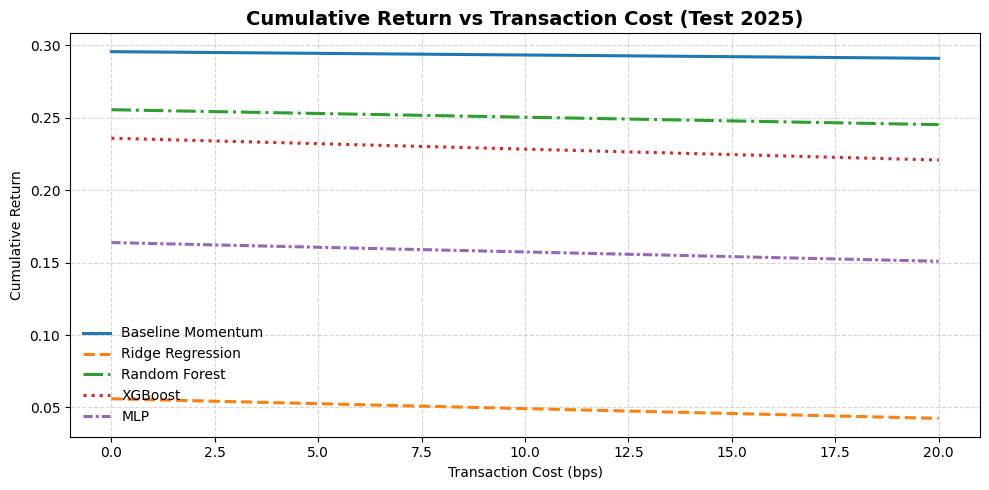

In [11]:
cost_bps = [0, 10, 20]

baseline_cum = [
    base_costs["cost_0bps"]["cumulative_return"],
    base_costs["cost_10bps"]["cumulative_return"],
    base_costs["cost_20bps"]["cumulative_return"],
]

ridge_cum = [
    ridge_costs["cost_0bps"]["cumulative_return"],
    ridge_costs["cost_10bps"]["cumulative_return"],
    ridge_costs["cost_20bps"]["cumulative_return"],
]

rf_cum = [
    rf_costs["cost_0bps"]["cumulative_return"],
    rf_costs["cost_10bps"]["cumulative_return"],
    rf_costs["cost_20bps"]["cumulative_return"],
]

xgb_cum = [
    xgb_costs["cost_0bps"]["cumulative_return"],
    xgb_costs["cost_10bps"]["cumulative_return"],
    xgb_costs["cost_20bps"]["cumulative_return"],
]

mlp_cum = [
    mlp_costs["cost_0bps"]["cumulative_return"],
    mlp_costs["cost_10bps"]["cumulative_return"],
    mlp_costs["cost_20bps"]["cumulative_return"],
]

plt.figure(figsize=(10, 5))
plt.plot(cost_bps, baseline_cum, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_cum, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, rf_cum, label="Random Forest", linewidth=2.2, linestyle="-.")
plt.plot(cost_bps, xgb_cum, label="XGBoost", linewidth=2.2, linestyle=":")
plt.plot(cost_bps, mlp_cum, label="MLP", linewidth=2.2, linestyle=(0, (3, 1, 1, 1)))
plt.title("Cumulative Return vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 5. Cost-adjusted Sharpe comparison

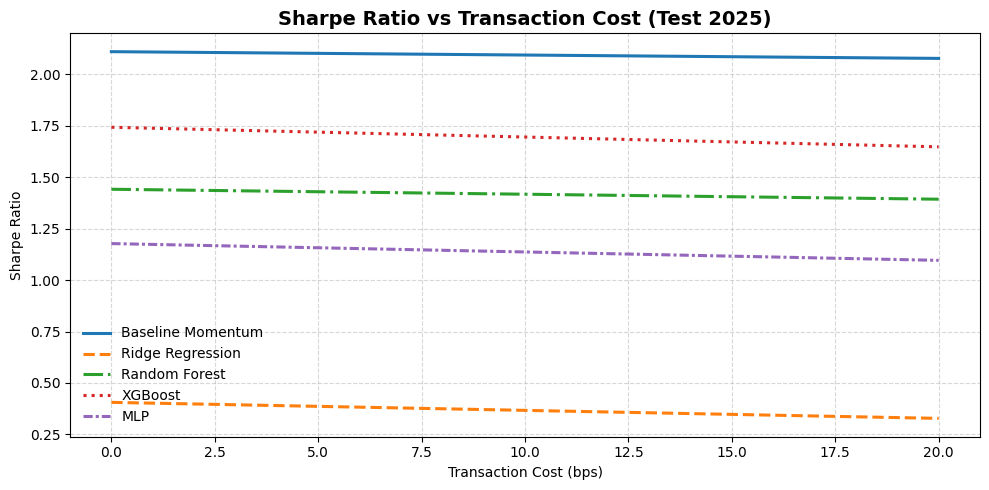

In [12]:
baseline_sharpe = [
    base_costs["cost_0bps"]["sharpe_ratio"],
    base_costs["cost_10bps"]["sharpe_ratio"],
    base_costs["cost_20bps"]["sharpe_ratio"],
]

ridge_sharpe = [
    ridge_costs["cost_0bps"]["sharpe_ratio"],
    ridge_costs["cost_10bps"]["sharpe_ratio"],
    ridge_costs["cost_20bps"]["sharpe_ratio"],
]

rf_sharpe = [
    rf_costs["cost_0bps"]["sharpe_ratio"],
    rf_costs["cost_10bps"]["sharpe_ratio"],
    rf_costs["cost_20bps"]["sharpe_ratio"],
]

xgb_sharpe = [
    xgb_costs["cost_0bps"]["sharpe_ratio"],
    xgb_costs["cost_10bps"]["sharpe_ratio"],
    xgb_costs["cost_20bps"]["sharpe_ratio"],
]

mlp_sharpe = [
    mlp_costs["cost_0bps"]["sharpe_ratio"],
    mlp_costs["cost_10bps"]["sharpe_ratio"],
    mlp_costs["cost_20bps"]["sharpe_ratio"],
]

plt.figure(figsize=(10, 5))
plt.plot(cost_bps, baseline_sharpe, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_sharpe, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, rf_sharpe, label="Random Forest", linewidth=2.2, linestyle="-.")
plt.plot(cost_bps, xgb_sharpe, label="XGBoost", linewidth=2.2, linestyle=":")
plt.plot(cost_bps, mlp_sharpe, label="MLP", linewidth=2.2, linestyle=(0, (3, 1, 1, 1)))
plt.title("Sharpe Ratio vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold")
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Sharpe Ratio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

## 6. Compact summary table (Test 2025)

In [13]:
summary_table = pd.DataFrame({
    "Strategy": ["Baseline", "Ridge", "Random Forest", "XGBoost", "MLP"],
    "Gross_Return_2025": [
        base_test["cumulative_return"],
        ridge_test["cumulative_return"],
        rf_test["cumulative_return"],
        xgb_test["cumulative_return"],
        mlp_test["cumulative_return"],
    ],
    "Return_10bps": [
        base_costs["cost_10bps"]["cumulative_return"],
        ridge_costs["cost_10bps"]["cumulative_return"],
        rf_costs["cost_10bps"]["cumulative_return"],
        xgb_costs["cost_10bps"]["cumulative_return"],
        mlp_costs["cost_10bps"]["cumulative_return"],
    ],
    "Return_20bps": [
        base_costs["cost_20bps"]["cumulative_return"],
        ridge_costs["cost_20bps"]["cumulative_return"],
        rf_costs["cost_20bps"]["cumulative_return"],
        xgb_costs["cost_20bps"]["cumulative_return"],
        mlp_costs["cost_20bps"]["cumulative_return"],
    ],
    "Sharpe_20bps": [
        base_costs["cost_20bps"]["sharpe_ratio"],
        ridge_costs["cost_20bps"]["sharpe_ratio"],
        rf_costs["cost_20bps"]["sharpe_ratio"],
        xgb_costs["cost_20bps"]["sharpe_ratio"],
        mlp_costs["cost_20bps"]["sharpe_ratio"],
    ],
    "Avg_Turnover": [
        base_test["avg_turnover"],
        ridge_test["avg_turnover"],
        rf_test["avg_turnover"],
        xgb_test["avg_turnover"],
        mlp_test["avg_turnover"],
    ]
})

display(summary_table.sort_values("Return_20bps", ascending=False))

,Strategy,Gross_Return_2025,Return_10bps,Return_20bps,Sharpe_20bps,Avg_Turnover
0,Baseline,0.295569,0.293265,0.290966,2.076449,0.150000
2,Random Forest,0.255496,0.250342,0.245207,1.392556,0.381818
3,XGBoost,0.235840,0.228286,0.220773,1.646906,0.568182
4,MLP,0.163806,0.157333,0.150891,1.095547,0.513636
1,Ridge,0.055996,0.049203,0.042449,0.328015,0.590909


## 7. Save report tables and figures

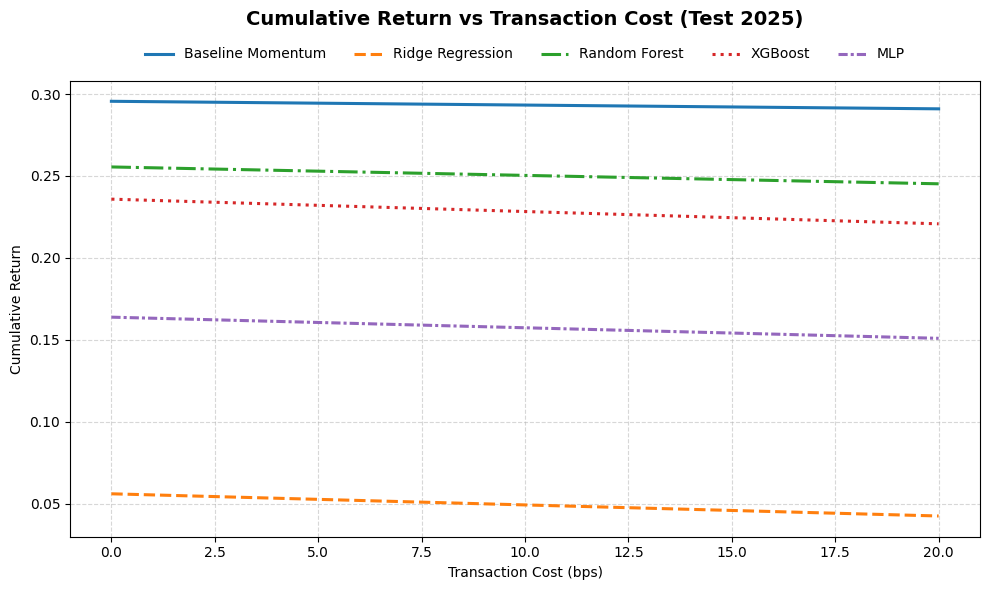

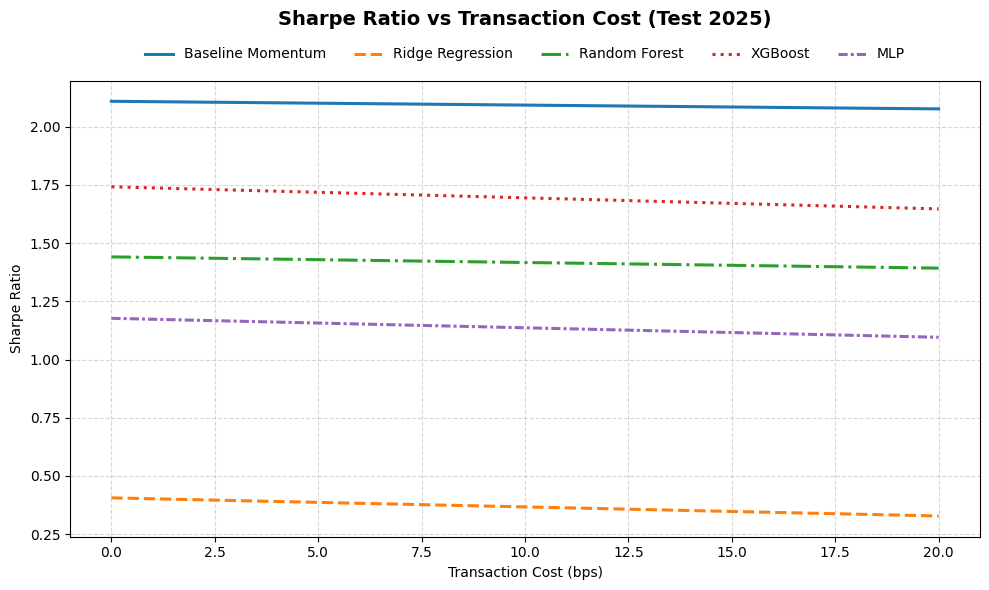

Saved figures and tables to: reports/figures/results_all_models_with_mlp


In [14]:
OUT_DIR = "reports/figures/results_all_models_with_mlp"
os.makedirs(OUT_DIR, exist_ok=True)

gross_table.to_csv(os.path.join(OUT_DIR, "gross_strategy_metrics_test2025.csv"), index=False)
pred_table.to_csv(os.path.join(OUT_DIR, "prediction_metrics_test2025.csv"), index=False)
summary_table.to_csv(os.path.join(OUT_DIR, "summary_table_test2025.csv"), index=False)

plt.figure(figsize=(10, 6))
plt.plot(cost_bps, baseline_cum, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_cum, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, rf_cum, label="Random Forest", linewidth=2.2, linestyle="-.")
plt.plot(cost_bps, xgb_cum, label="XGBoost", linewidth=2.2, linestyle=":")
plt.plot(cost_bps, mlp_cum, label="MLP", linewidth=2.2, linestyle=(0, (3, 1, 1, 1)))
plt.title("Cumulative Return vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold",pad=40)
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Cumulative Return")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=5
)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "cumulative_return_vs_cost_all_models.png"), dpi=300)
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(cost_bps, baseline_sharpe, label="Baseline Momentum", linewidth=2.2, linestyle="-")
plt.plot(cost_bps, ridge_sharpe, label="Ridge Regression", linewidth=2.2, linestyle="--")
plt.plot(cost_bps, rf_sharpe, label="Random Forest", linewidth=2.2, linestyle="-.")
plt.plot(cost_bps, xgb_sharpe, label="XGBoost", linewidth=2.2, linestyle=":")
plt.plot(cost_bps, mlp_sharpe, label="MLP", linewidth=2.2, linestyle=(0, (3, 1, 1, 1)))
plt.title("Sharpe Ratio vs Transaction Cost (Test 2025)", fontsize=14, fontweight="bold", pad=40)
plt.xlabel("Transaction Cost (bps)")
plt.ylabel("Sharpe Ratio")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.1),
    ncol=5
)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, "sharpe_vs_cost_all_models.png"), dpi=300)
plt.show()

print("Saved figures and tables to:", OUT_DIR)

## 8. Final interpretation

Key findings from the 2025 hold-out comparison:

- The **baseline momentum strategy** remained the strongest and most robust overall, especially after transaction costs.
- **Ridge regression** was the weakest ML model and deteriorated further after costs.
- **Random Forest** delivered the best balance among the ML models, combining useful ranking performance with lower turnover than Ridge and XGBoost.
- **XGBoost** produced strong results and clearly outperformed Ridge, but still did not surpass the baseline in the 2025 hold-out period.
- **MLP** improved on Ridge but remained below the tree-based models, suggesting that a simple feed-forward neural network was not the best choice for this tabular financial dataset.
- Overall, increasing model complexity did not guarantee better practical performance; turnover and cost sensitivity remained central to model usefulness.

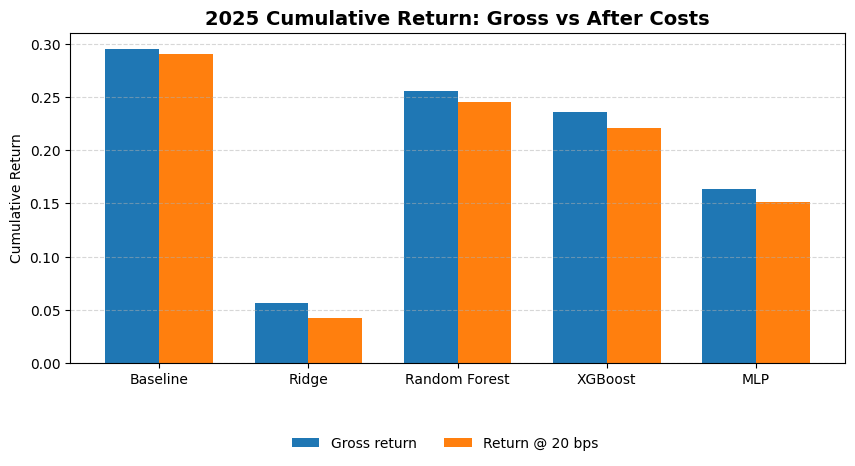

In [15]:
models = ["Baseline", "Ridge", "Random Forest", "XGBoost", "MLP"]

gross_returns = [
    base_test["cumulative_return"],
    ridge_test["cumulative_return"],
    rf_test["cumulative_return"],
    xgb_test["cumulative_return"],
    mlp_test["cumulative_return"],
]

net_returns_20bps = [
    base_costs["cost_20bps"]["cumulative_return"],
    ridge_costs["cost_20bps"]["cumulative_return"],
    rf_costs["cost_20bps"]["cumulative_return"],
    xgb_costs["cost_20bps"]["cumulative_return"],
    mlp_costs["cost_20bps"]["cumulative_return"],
]

x = range(len(models))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar([i - width/2 for i in x], gross_returns, width=width, label="Gross return")
ax.bar([i + width/2 for i in x], net_returns_20bps, width=width, label="Return @ 20 bps")

ax.set_title("2025 Cumulative Return: Gross vs After Costs", fontsize=14, fontweight="bold")
ax.set_ylabel("Cumulative Return")
ax.set_xticks(list(x))
ax.set_xticklabels(models)
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

fig.subplots_adjust(bottom=0.22)
fig.legend(loc="lower center", bbox_to_anchor=(0.5, 0.02), ncol=2, frameon=False)

plt.savefig(os.path.join(OUT_DIR, "gross_vs_20bps_return.png"), dpi=300, bbox_inches="tight")
plt.show()

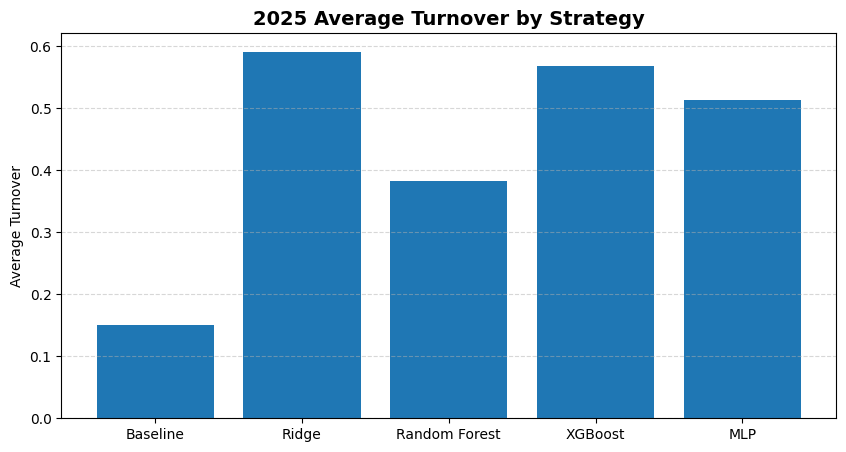

In [16]:
avg_turnover = [
    base_test["avg_turnover"],
    ridge_test["avg_turnover"],
    rf_test["avg_turnover"],
    xgb_test["avg_turnover"],
    mlp_test["avg_turnover"],
]

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(models, avg_turnover)

ax.set_title("2025 Average Turnover by Strategy", fontsize=14, fontweight="bold")
ax.set_ylabel("Average Turnover")
ax.grid(True, axis="y", linestyle="--", alpha=0.5)

plt.savefig(os.path.join(OUT_DIR, "avg_turnover_2025.png"), dpi=300, bbox_inches="tight")
plt.show()